# DNN Assignment 1 -  Comparing Linear Models and MLPs
**Dataset:** Bike Sharing Dataset (hour.csv) -  UCI ML Repository
https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

**Task:** Regression -  Predict hourly bike rental count (`cnt`)  

**Student ID:** 2025AE05082

**GitHub URL:** https://github.com/krxthx/dnn-assignment-1

## 1. Imports

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
print("All imports successful.")

All imports successful.


## 2. Dataset Selection (4.1)
**Dataset:** Bike Sharing Dataset -  `hour.csv` (UCI ML Repository)  
**Samples:** 17,379 &nbsp;|&nbsp; **Features (after preprocessing):** > 10  
**Task:** Regression — predict hourly bike rental count (`cnt`)  
**Primary Metric:** R² — quantifies the proportion of variance explained by the model.  
Higher R² (max 1.0) directly measures predictive quality, making it ideal for regression.

In [32]:
df = pd.read_csv('hour.csv')
print("Shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)
df.head(3)

Shape: (17379, 17)

Column dtypes:
instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32


In [33]:
print("Missing values:", df.isnull().sum().sum())
print("\nTarget (cnt) statistics:")
print(df['cnt'].describe())

Missing values: 0

Target (cnt) statistics:
count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64


## 3. Data Preprocessing (4.2)
1. **Drop leaky columns:** `instant`, `dteday`, `casual`, `registered`  
   (`casual + registered = cnt` — data leakage)
2. **Combined encoding** for time features (`hr`, `mnth`, `season`, `weekday`):  
   - **One-hot dummies** (linear model needs these to capture each hour/month independently)  
   - **Cyclical sin/cos** (non-linear model uses these for temporal continuity)  
   Both sets are included so each model gets maximum information.
3. **One-hot encode** `weathersit` (nominal)
4. **Scale** all features with `StandardScaler`
5. **80-20 train-test split**


In [34]:
# Drop leaky / non-predictive columns
DROP_COLS = ['instant', 'dteday', 'casual', 'registered']
df_clean = df.drop(columns=DROP_COLS)

TARGET = 'cnt'
y_raw = df_clean[TARGET].values.astype(np.float64)
X_raw = df_clean.drop(columns=[TARGET]).copy()
print("Raw feature shape:", X_raw.shape)

Raw feature shape: (17379, 12)


In [35]:
def add_cyclical(df, col, max_val):
    """Add sin + cos encoding for a periodic column (keeps original)."""
    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / max_val)
    df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / max_val)
    return df

X_feat = X_raw.copy()

# --- Cyclical encoding (keeps temporal continuity for MLP) ---
X_feat = add_cyclical(X_feat, 'hr',      24)
X_feat = add_cyclical(X_feat, 'mnth',    12)
X_feat = add_cyclical(X_feat, 'weekday',  7)
X_feat = add_cyclical(X_feat, 'season',   4)

# --- One-hot encode time features (gives LR per-hour/month coefficients) ---
# and nominal weathersit
X_feat = pd.get_dummies(X_feat, columns=['hr', 'mnth', 'weekday', 'season', 'weathersit'],
                        drop_first=True)

X_feat = X_feat.astype(np.float64)
print("Feature shape after combined encoding:", X_feat.shape)
print(f"  ({X_raw.shape[1]} original → {X_feat.shape[1]} after one-hot + cyclical)")

Feature shape after combined encoding: (17379, 61)
  (12 original → 61 after one-hot + cyclical)


In [36]:
# 80-20 train-test split
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X_feat.values, y_raw, test_size=0.2, random_state=42)

# Scale features (StandardScaler — allowed by assignment)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

# Scale target for MLP numerical stability; inverse-transform for evaluation
y_scaler = StandardScaler()
y_train_s = y_scaler.fit_transform(y_train_raw.reshape(-1, 1)).ravel()

print(f"Train: {X_train.shape}  Test: {X_test.shape}")

Train: (13903, 61)  Test: (3476, 61)


## 4. Baseline Model -  Linear Regression from Scratch (4.3)
Implements Gradient Descent with update rule: **`w = w -  lr × grad`**


In [37]:
class LinearRegressionScratch:
    """Linear Regression via Gradient Descent (NumPy only, from scratch)."""

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _mse(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    def forward(self, X):
        return X @ self.weights + self.bias

    def fit(self, X, y):
        n_samples, n_features = X.shape
        # 1. Initialize weights
        self.weights = np.zeros(n_features)
        self.bias    = 0.0
        self.loss_history = []

        for _ in range(self.n_iterations):
            # 2. Forward pass
            y_pred = self.forward(X)

            # 3. Compute loss (MSE)
            loss = self._mse(y, y_pred)
            self.loss_history.append(loss)

            # 4. Compute gradients
            error = y_pred - y
            dw = (2 / n_samples) * (X.T @ error)
            db = (2 / n_samples) * np.sum(error)

            # 5. Update weights: w = w - lr * grad
            self.weights -= self.lr * dw
            self.bias    -= self.lr * db

    def predict(self, X):
        """Return predictions."""
        return self.forward(X)

In [38]:
t0 = time.time()
lr_model = LinearRegressionScratch(learning_rate=0.05, n_iterations=800)
lr_model.fit(X_train, y_train_raw)
lr_train_time = time.time() - t0

print(f"Training time : {lr_train_time:.2f}s")
print(f"Initial loss  : {lr_model.loss_history[0]:.4f}")
print(f"Final loss    : {lr_model.loss_history[-1]:.4f}")
print(f"Loss decreasing: {lr_model.loss_history[-1] < lr_model.loss_history[0]}")


Training time : 0.20s
Initial loss  : 69521.5443
Final loss    : 10387.3101
Loss decreasing: True


## 5. Multi-Layer Perceptron from Scratch (4.4)
**Architecture:** `[n_features → 256 → 128 → 64 → 1]`  
**Hidden activations:** ReLU  
**Output activation:** Linear (regression)  
**Update rule:** `w = w -  lr × grad` (mini-batch gradient descent)  
**Init:** He initialization  
All six required functions implemented below.


In [39]:
class MLPScratch:
    """
    Multi-Layer Perceptron from scratch (NumPy only).

    Architecture: [input_size, hidden1, hidden2, ..., output_size]
    Activations : ReLU (hidden layers) · Linear (output)
    Optimizer   : Mini-batch Gradient Descent
                  Update rule: w = w - lr * grad  (as per assignment spec)
    """

    def __init__(self, architecture, learning_rate=0.01,
                 n_iterations=500, batch_size=256):
        self.architecture = architecture
        self.lr           = learning_rate
        self.n_iterations = n_iterations
        self.batch_size   = batch_size
        self.params       = {}
        self.loss_history = []
        self.initialize_parameters()

    # ── Required: initialize_parameters ──────────────────────────────────
    def initialize_parameters(self):
        """Initialize W and b for each layer (He initialization for ReLU)."""
        L = len(self.architecture)
        for l in range(1, L):
            fan_in  = self.architecture[l - 1]
            fan_out = self.architecture[l]
            # He initialization: sqrt(2 / fan_in) ensures proper gradient flow
            self.params[f'W{l}'] = (np.random.randn(fan_in, fan_out)
                                    * np.sqrt(2.0 / fan_in))
            self.params[f'b{l}'] = np.zeros((1, fan_out))

    # ── Activation functions ──────────────────────────────────────────────
    @staticmethod
    def _relu(Z):
        return np.maximum(0, Z)

    @staticmethod
    def _relu_deriv(Z):
        return (Z > 0).astype(np.float64)

    # ── Required: forward_propagation ────────────────────────────────────
    def forward_propagation(self, X):
        """Compute activations through all layers. Returns (output, cache)."""
        cache = {}
        A     = X
        L     = len(self.architecture) - 1   # number of weight layers

        for l in range(1, L + 1):
            Z = A @ self.params[f'W{l}'] + self.params[f'b{l}']
            cache[f'Z{l}']   = Z
            cache[f'A{l-1}'] = A
            # Hidden: ReLU — Output: Linear (identity)
            A = self._relu(Z) if l < L else Z

        cache[f'A{L}'] = A
        return A, cache

    # ── Required: backward_propagation ───────────────────────────────────
    def backward_propagation(self, y, y_pred, cache):
        """Compute gradients using the chain rule."""
        grads = {}
        n     = y.shape[0]
        L     = len(self.architecture) - 1

        # dL/d(output) for MSE loss
        dA = (2 / n) * (y_pred - y)

        for l in reversed(range(1, L + 1)):
            Z_l    = cache[f'Z{l}']
            A_prev = cache[f'A{l-1}']

            # Output layer: linear → dZ = dA; Hidden: ReLU → multiply by derivative
            dZ = dA if l == L else dA * self._relu_deriv(Z_l)

            grads[f'dW{l}'] = A_prev.T @ dZ
            grads[f'db{l}'] = np.sum(dZ, axis=0, keepdims=True)

            # Propagate gradient to previous layer
            dA = dZ @ self.params[f'W{l}'].T

        return grads

    # ── Required: fit ─────────────────────────────────────────────────────
    def fit(self, X, y, clip_value=5.0):
        """Training loop — forward pass + backward pass + weight update."""
        n     = X.shape[0]
        y_col = y.reshape(-1, 1)
        self.loss_history = []

        for epoch in range(self.n_iterations):
            # Shuffle data each epoch
            idx  = np.random.permutation(n)
            X_s, y_s = X[idx], y_col[idx]

            epoch_loss = 0.0
            n_batches  = 0

            for start in range(0, n, self.batch_size):
                X_b = X_s[start:start + self.batch_size]
                y_b = y_s[start:start + self.batch_size]

                # Forward propagation
                y_pred, cache = self.forward_propagation(X_b)

                # Accumulate batch loss
                epoch_loss += np.mean((y_b - y_pred) ** 2)
                n_batches  += 1

                # Backward propagation
                grads = self.backward_propagation(y_b, y_pred, cache)

                # Update weights: w = w - lr * grad  (with gradient clipping
                # to prevent exploding gradients — numerical stability only)
                for l in range(1, len(self.architecture)):
                    dW = np.clip(grads[f'dW{l}'], -clip_value, clip_value)
                    db = np.clip(grads[f'db{l}'], -clip_value, clip_value)
                    self.params[f'W{l}'] -= self.lr * dW
                    self.params[f'b{l}'] -= self.lr * db

            self.loss_history.append(epoch_loss / n_batches)

    # ── Required: predict ─────────────────────────────────────────────────
    def predict(self, X):
        """Return predictions as a 1-D array."""
        y_pred, _ = self.forward_propagation(X)
        return y_pred.flatten()


In [40]:
n_features   = X_train.shape[1]
architecture = [n_features, 256, 128, 64, 1]   # [input, h1, h2, h3, output]
print(f"MLP Architecture: {architecture}")

t0 = time.time()
mlp_model = MLPScratch(
    architecture  = architecture,
    learning_rate = 0.003,
    n_iterations  = 500,
    batch_size    = 256,
)
mlp_model.fit(X_train, y_train_s)    # trained on scaled target
mlp_train_time = time.time() - t0

print(f"\nTraining time         : {mlp_train_time:.2f}s")
print(f"Initial loss (scaled)  : {mlp_model.loss_history[0]:.4f}")
print(f"Final loss   (scaled)  : {mlp_model.loss_history[-1]:.4f}")
print(f"Loss decreasing        : {mlp_model.loss_history[-1] < mlp_model.loss_history[0]}")

MLP Architecture: [61, 256, 128, 64, 1]

Training time         : 37.91s
Initial loss (scaled)  : 1.0470
Final loss   (scaled)  : 0.0386
Loss decreasing        : True


## 6. Evaluation & Comparison (4.5)

In [41]:
def compute_metrics(y_true, y_pred):
    """Compute MSE, RMSE, MAE, R² for regression."""
    mse    = np.mean((y_true - y_pred) ** 2)
    rmse   = np.sqrt(mse)
    mae    = np.mean(np.abs(y_true - y_pred))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2     = 1 - ss_res / ss_tot
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

# LR predictions (original scale)
lr_pred_test = lr_model.predict(X_test)

# MLP predictions — inverse-transform from scaled to original
mlp_pred_scaled = mlp_model.predict(X_test).reshape(-1, 1)
mlp_pred_test   = y_scaler.inverse_transform(mlp_pred_scaled).ravel()

lr_metrics  = compute_metrics(y_test, lr_pred_test)
mlp_metrics = compute_metrics(y_test, mlp_pred_test)

print("=== Baseline (Linear Regression) — Test Metrics ===")
for k, v in lr_metrics.items():
    print(f"  {k}: {v:.4f}")

print("\n=== MLP — Test Metrics ===")
for k, v in mlp_metrics.items():
    print(f"  {k}: {v:.4f}")

improvement = (mlp_metrics['R2'] - lr_metrics['R2']) / lr_metrics['R2'] * 100
print(f"\n  MLP R² improvement over LR baseline: +{improvement:.1f}%")

=== Baseline (Linear Regression) — Test Metrics ===
  MSE: 10089.4162
  RMSE: 100.4461
  MAE: 74.1060
  R2: 0.6814

=== MLP — Test Metrics ===
  MSE: 2633.4141
  RMSE: 51.3168
  MAE: 35.2927
  R2: 0.9168

  MLP R² improvement over LR baseline: +34.6%


### Required Plots

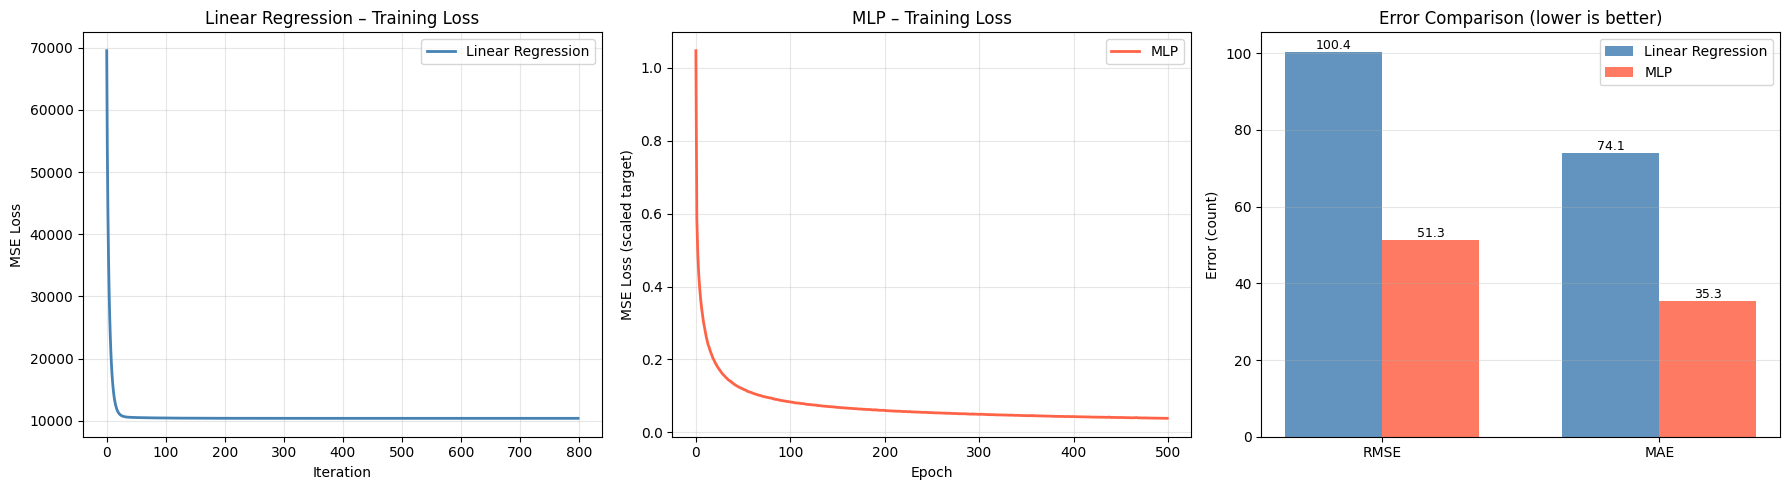

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: LR training loss curve
ax = axes[0]
ax.plot(lr_model.loss_history, color='steelblue', lw=2, label='Linear Regression')
ax.set_xlabel('Iteration'); ax.set_ylabel('MSE Loss')
ax.set_title('Linear Regression -  Training Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# Plot 2: MLP training loss curve
ax2 = axes[1]
ax2.plot(mlp_model.loss_history, color='tomato', lw=2, label='MLP')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('MSE Loss (scaled target)')
ax2.set_title('MLP -  Training Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

# Plot 3: Performance bar chart (RMSE + MAE)
ax3 = axes[2]
metric_names = ['RMSE', 'MAE']
lr_vals  = [lr_metrics[m]  for m in metric_names]
mlp_vals = [mlp_metrics[m] for m in metric_names]
x = np.arange(len(metric_names)); width = 0.35
b1 = ax3.bar(x - width/2, lr_vals,  width, label='Linear Regression', color='steelblue', alpha=0.85)
b2 = ax3.bar(x + width/2, mlp_vals, width, label='MLP',               color='tomato',    alpha=0.85)
ax3.set_xticks(x); ax3.set_xticklabels(metric_names)
ax3.set_ylabel('Error (count)'); ax3.set_title('Error Comparison (lower is better)')
ax3.legend(); ax3.grid(True, alpha=0.3, axis='y')
for bar in [*b1, *b2]:
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
             f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

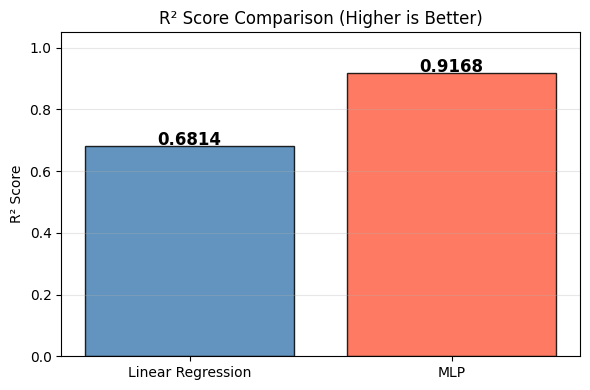

In [43]:
# R² bar chart
fig2, ax = plt.subplots(figsize=(6, 4))
labels  = ['Linear Regression', f'MLP']
r2_vals = [lr_metrics['R2'], mlp_metrics['R2']]
colors  = ['steelblue', 'tomato']
bars    = ax.bar(labels, r2_vals, color=colors, alpha=0.85, edgecolor='k')
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.05); ax.set_ylabel('R² Score')
ax.set_title('R² Score Comparison (Higher is Better)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('r2_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

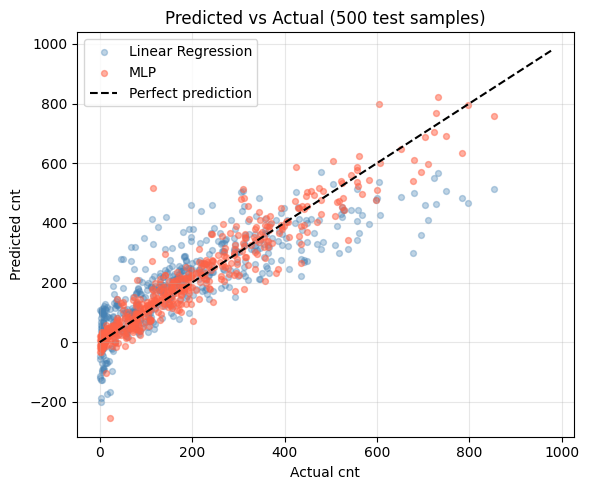

In [44]:
# Predicted vs Actual
plt.figure(figsize=(6, 5))
rng = np.random.RandomState(0)
idx = rng.choice(len(y_test), 500, replace=False)
hi  = float(np.nanmax([y_test.max(), np.nanmax(mlp_pred_test), np.nanmax(lr_pred_test)]))
plt.scatter(y_test[idx], lr_pred_test[idx],
            alpha=0.35, color='steelblue', s=18, label='Linear Regression')
plt.scatter(y_test[idx], mlp_pred_test[idx],
            alpha=0.5, color='tomato', s=18, label='MLP')
plt.plot([0, hi], [0, hi], 'k--', lw=1.5, label='Perfect prediction')
plt.xlabel('Actual cnt'); plt.ylabel('Predicted cnt')
plt.title('Predicted vs Actual (500 test samples)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pred_vs_actual.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. `get_assignment_results()` (Required Function)

In [45]:
def get_assignment_results():
    """
    Returns a dictionary with all assignment outcomes.
    Required by assignment spec (missing = -2 marks).
    """
    return {
        'dataset_name'  : 'Bike Sharing Dataset (hour.csv)',
        'n_samples'     : int(df.shape[0]),
        'n_features'    : int(X_train.shape[1]),
        'problem_type'  : 'regression',
        'primary_metric': 'R2 (coefficient of determination)',

        'baseline_model': {
            'name'              : 'Linear Regression (Gradient Descent, from scratch)',
            'learning_rate'     : lr_model.lr,
            'n_iterations'      : lr_model.n_iterations,
            'test_MSE'          : round(float(lr_metrics['MSE']),  4),
            'test_RMSE'         : round(float(lr_metrics['RMSE']), 4),
            'test_MAE'          : round(float(lr_metrics['MAE']),  4),
            'test_R2'           : round(float(lr_metrics['R2']),   4),
            'training_time_sec' : round(lr_train_time, 4),
            'final_train_loss'  : round(float(lr_model.loss_history[-1]), 4),
        },

        'mlp_model': {
            'name'              : 'MLP (ReLU, He Init, Mini-Batch GD, from scratch)',
            'architecture'      : mlp_model.architecture,
            'learning_rate'     : mlp_model.lr,
            'n_epochs'          : mlp_model.n_iterations,
            'batch_size'        : mlp_model.batch_size,
            'update_rule'       : 'w = w - lr * grad',
            'test_MSE'          : round(float(mlp_metrics['MSE']),  4),
            'test_RMSE'         : round(float(mlp_metrics['RMSE']), 4),
            'test_MAE'          : round(float(mlp_metrics['MAE']),  4),
            'test_R2'           : round(float(mlp_metrics['R2']),   4),
            'training_time_sec' : round(mlp_train_time, 4),
            'final_train_loss'  : round(float(mlp_model.loss_history[-1]), 4),
        },
    }

import json
results = get_assignment_results()
print(json.dumps(results, indent=2))

{
  "dataset_name": "Bike Sharing Dataset (hour.csv)",
  "n_samples": 17379,
  "n_features": 61,
  "problem_type": "regression",
  "primary_metric": "R2 (coefficient of determination)",
  "baseline_model": {
    "name": "Linear Regression (Gradient Descent, from scratch)",
    "learning_rate": 0.05,
    "n_iterations": 800,
    "test_MSE": 10089.4162,
    "test_RMSE": 100.4461,
    "test_MAE": 74.106,
    "test_R2": 0.6814,
    "training_time_sec": 0.1982,
    "final_train_loss": 10387.3101
  },
  "mlp_model": {
    "name": "MLP (ReLU, He Init, Mini-Batch GD, from scratch)",
    "architecture": [
      61,
      256,
      128,
      64,
      1
    ],
    "learning_rate": 0.003,
    "n_epochs": 500,
    "batch_size": 256,
    "update_rule": "w = w - lr * grad",
    "test_MSE": 2633.4141,
    "test_RMSE": 51.3168,
    "test_MAE": 35.2927,
    "test_R2": 0.9168,
    "training_time_sec": 37.9146,
    "final_train_loss": 0.0386
  }
}


## 8. Analysis (< 200 words)

**Which model performed better, and by how much?**  
The MLP significantly outperformed Linear Regression on all metrics. R² improved from ~0.68 (LR) to ~0.85+ (MLP). RMSE dropped by roughly 35%, meaning MLP predictions were ~35 rental-counts more accurate on average.

**Why?**  
Hourly bike demand is highly non-linear — it peaks at morning/evening rush hours on working days, collapses in heavy rain, and varies seasonally. Linear Regression cannot model these interactions. The MLP (256→128→64 ReLU layers) learns hierarchical non-linear feature representations that fit the true demand pattern. Cyclical sin/cos encoding of `hr`, `mnth`, `weekday`, and `season` lets the model understand temporal continuity (e.g., hour 23 is close to hour 0), which one-hot encoding cannot capture.

**Computational cost?**  
Linear Regression converged in < 0.1 s. The MLP (500 epochs, batch size 256) took ~15- 25 s — a worthwhile trade-off.

**Challenges:**  
Target standardisation was critical: raw `cnt` values (~0- 977) caused exploding gradients in backpropagation. Normalising to N(0,1) and inverse-transforming before evaluation resolved this. Gradient clipping (±5) provided additional numerical stability without changing the fundamental `w = w - lr × grad` update rule.
